# Diabetic Risk Prediction Model

This notebook analyzes the Pima Indians Diabetes Dataset to predict the risk of diabetes.
It includes data cleaning (handling missing values), Exploratory Data Analysis (EDA), and machine learning modeling using Random Forest.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

# Configuration
DATASET_PATH = "diabetes.csv"
MODEL_EXPORT_PATH = "diabetic_risk_model.joblib"
SCALER_EXPORT_PATH = "diabetic_risk_scaler.joblib"

In [2]:
# 1. Load Data
if os.path.exists(DATASET_PATH):
    df = pd.read_csv(DATASET_PATH)
    print("Dataset loaded successfully.")
    print(f"Shape: {df.shape}")
    display(df.head())
else:
    raise FileNotFoundError(f"Dataset not found at {DATASET_PATH}")

Dataset loaded successfully.
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Data Cleaning & Preprocessing
The dataset contains '0' values in columns where 0 is biologically impossible (e.g., Glucose, Blood Pressure, BMI). We will treat these as missing values and impute them.

In [3]:
# Check for zero values in critical columns
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Count of 0 values before cleaning:")
print((df[zero_columns] == 0).sum())

# Replace 0 with NaN
df[zero_columns] = df[zero_columns].replace(0, np.nan)

# Impute missing values with median
imputer = SimpleImputer(strategy='median')
df[zero_columns] = imputer.fit_transform(df[zero_columns])

print("\nData cleaned. Zeros imputed with median values.")

Count of 0 values before cleaning:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Data cleaned. Zeros imputed with median values.


## 3. Exploratory Data Analysis (EDA)

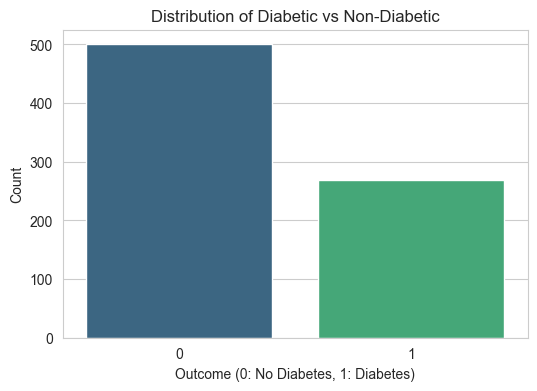

Outcome Balance:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [4]:
# Distribution of Outcome (Target)
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='viridis')
plt.title('Distribution of Diabetic vs Non-Diabetic')
plt.xlabel('Outcome (0: No Diabetes, 1: Diabetes)')
plt.ylabel('Count')
plt.show()

print("Outcome Balance:")
print(df['Outcome'].value_counts(normalize=True) * 100)

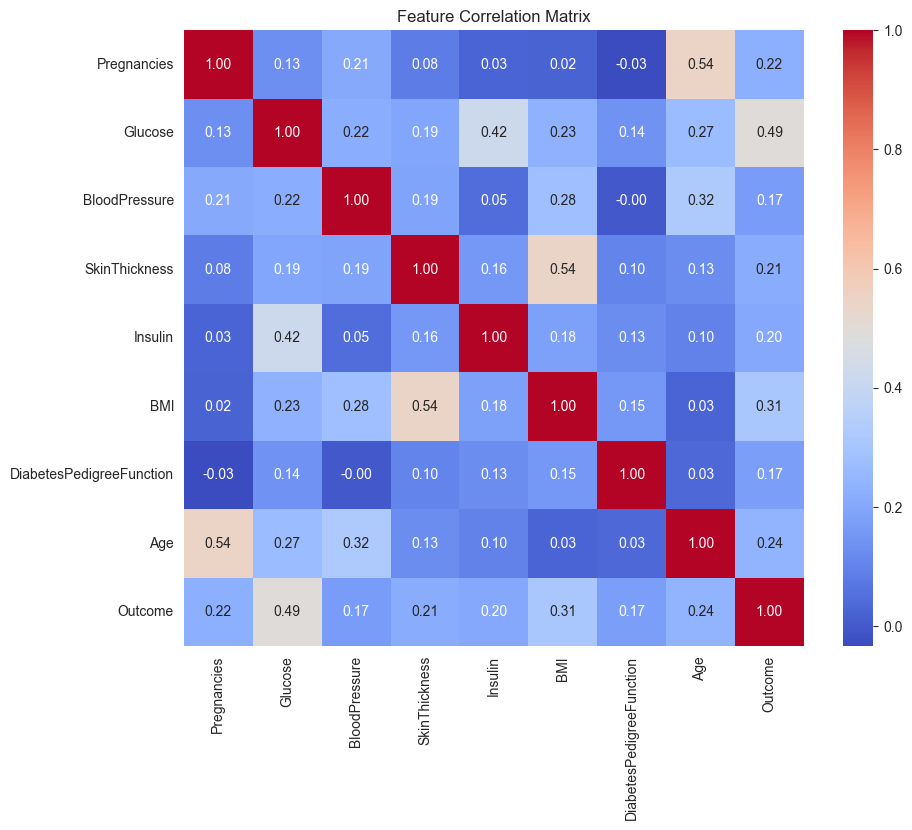

In [5]:
# Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

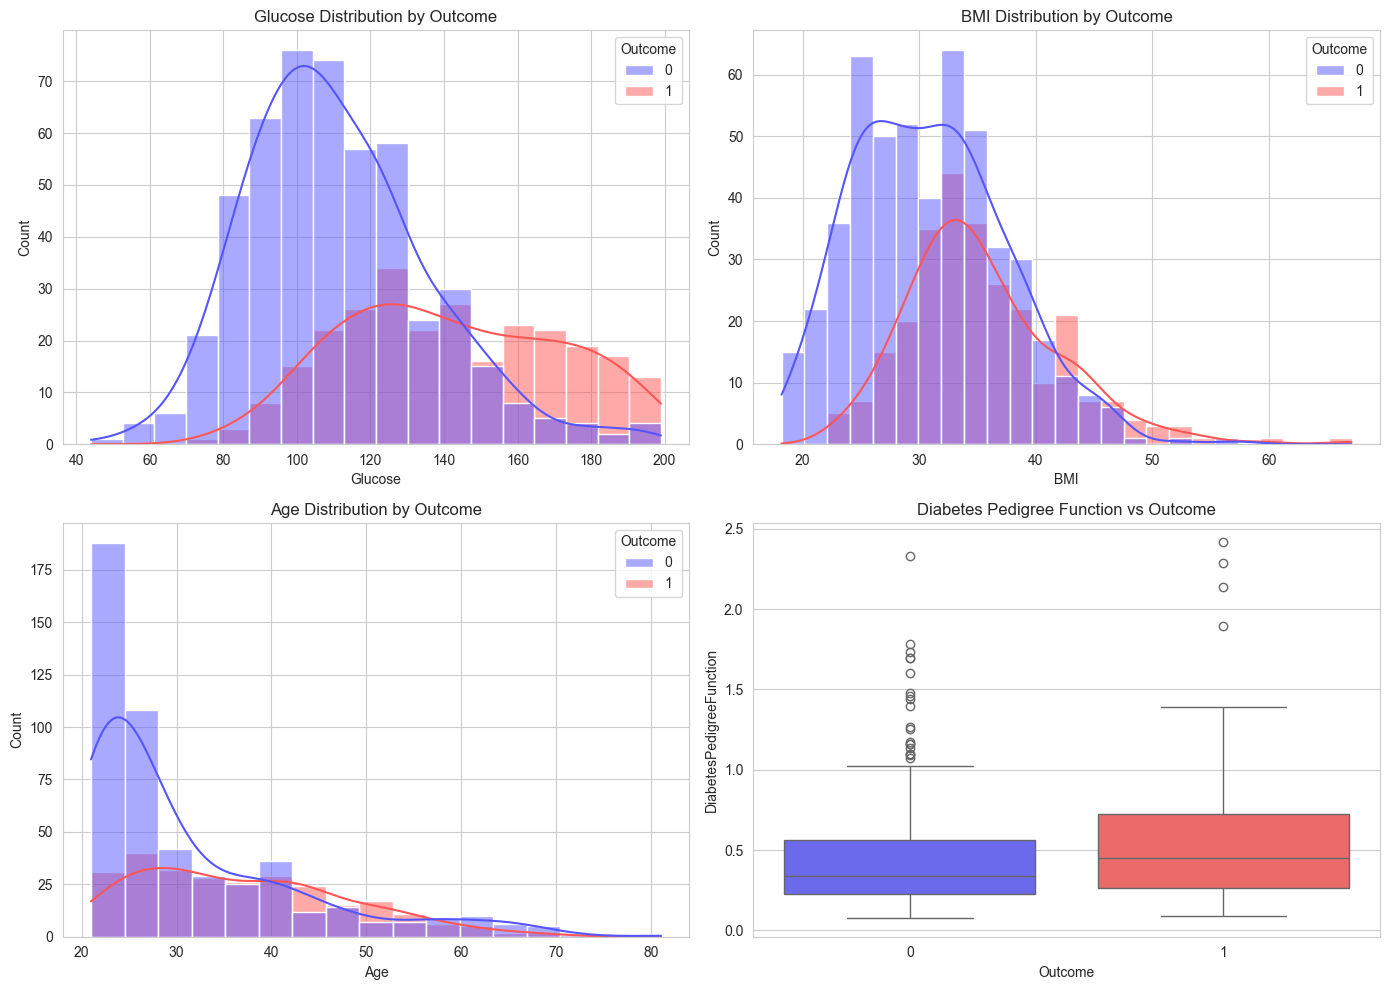

In [6]:
# Distribution of Key Features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data=df, x='Glucose', hue='Outcome', kde=True, ax=axes[0, 0], palette='seismic')
axes[0, 0].set_title('Glucose Distribution by Outcome')

sns.histplot(data=df, x='BMI', hue='Outcome', kde=True, ax=axes[0, 1], palette='seismic')
axes[0, 1].set_title('BMI Distribution by Outcome')

sns.histplot(data=df, x='Age', hue='Outcome', kde=True, ax=axes[1, 0], palette='seismic')
axes[1, 0].set_title('Age Distribution by Outcome')

sns.boxplot(x='Outcome', y='DiabetesPedigreeFunction', data=df, ax=axes[1, 1], palette='seismic')
axes[1, 1].set_title('Diabetes Pedigree Function vs Outcome')

plt.tight_layout()
plt.show()

## 4. Model Training & Evaluation

In [7]:
# Prepare Data
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 614
Testing samples: 154


In [8]:
# Model Comparison - Quick Check
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM': SVC(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

print("Model Comparison (Accuracy):")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    score = model.score(X_test_scaled, y_test)
    print(f"{name}: {score:.4f}")

Model Comparison (Accuracy):
Random Forest: 0.7792
Logistic Regression: 0.7078
SVM: 0.7403
Gradient Boosting: 0.7597


### Hyperparameter Tuning for Random Forest
We'll perform a manual simplified grid search to optimize the Random Forest model without overloading disk space.

In [9]:
best_score = 0
best_params = {}
best_rf = None

# Simplified parameter grid
n_estimators_list = [50, 100, 200]
max_depth_list = [None, 5, 10, 15]
min_samples_split_list = [2, 5, 10]

print("Tuning Random Forest...")
for n in n_estimators_list:
    for d in max_depth_list:
        for s in min_samples_split_list:
            rf = RandomForestClassifier(n_estimators=n, max_depth=d, min_samples_split=s, random_state=42)
            # Use CV for robust checking
            scores = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring='accuracy')
            mean_score = scores.mean()
            
            if mean_score > best_score:
                best_score = mean_score
                best_params = {'n_estimators': n, 'max_depth': d, 'min_samples_split': s}
                best_rf = rf

print(f"\nBest CV Accuracy: {best_score:.4f}")
print("Best Parameters:", best_params)

Tuning Random Forest...

Best CV Accuracy: 0.7737
Best Parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 2}


In [10]:
# Train Final Model with Best Parameters
best_rf.fit(X_train_scaled, y_train)
y_pred_final = best_rf.predict(X_test_scaled)

print("FINAL MODEL EVALUATION (Test Set)")
print("=" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("\nClassification Report:\n", classification_report(y_test, y_pred_final))

FINAL MODEL EVALUATION (Test Set)
Accuracy: 0.7597

Confusion Matrix:
 [[86 14]
 [23 31]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.86      0.82       100
           1       0.69      0.57      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.72       154
weighted avg       0.75      0.76      0.75       154



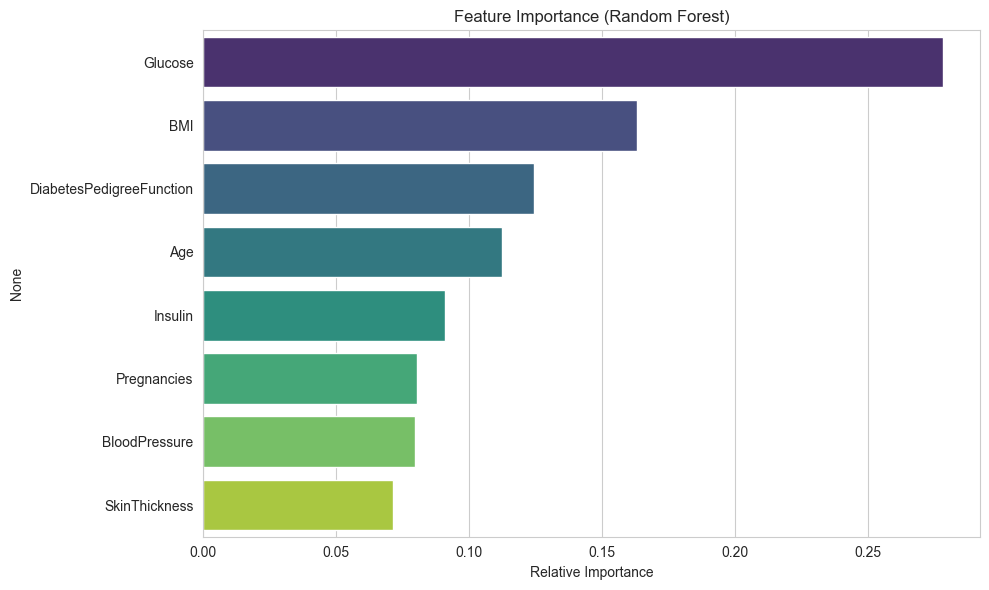

In [11]:
# Feature Importance
plt.figure(figsize=(10, 6))
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

sns.barplot(x=importances[indices], y=X.columns[indices], palette='viridis')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

In [12]:
# 5. Export Model and Scaler
joblib.dump(best_rf, MODEL_EXPORT_PATH)
joblib.dump(scaler, SCALER_EXPORT_PATH)
print(f"Model saved to {MODEL_EXPORT_PATH}")
print(f"Scaler saved to {SCALER_EXPORT_PATH}")

Model saved to diabetic_risk_model.joblib
Scaler saved to diabetic_risk_scaler.joblib
